<a href="https://colab.research.google.com/github/Paridhi1312/Internship-BIts/blob/main/Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step-1 Installing Dependency

In [1]:
!pip install transformers peft datasets accelerate torch --quiet

#Step-2 Load Data

In [2]:
import pandas as pd
from datasets import Dataset

acd = pd.read_csv("acd_concepts_clean.csv")
bcd = pd.read_csv("bcd_concepts_clean.csv")

def build_text(row):
    return (
        f"Concept: {row['concept']}\n\n"
        f"Worked Example: {row['worked_example']}\n\n"
        f"Task: {row['original_prompt']}\n"
    )

acd["text"] = acd.apply(build_text, axis=1)
bcd["text"] = bcd.apply(build_text, axis=1)

all_df = pd.concat([acd, bcd], ignore_index=True)
prompts = all_df["original_prompt"].tolist()   # used later for generation comparisons

dataset = Dataset.from_pandas(all_df[["text"]])
dataset = dataset.train_test_split(test_size=0.1, seed=42)

In [3]:
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "gpt2"

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

base_model = GPT2LMHeadModel.from_pretrained(model_name).to(device)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [4]:
import random
random.seed(1)
sample_prompts = random.sample(prompts, 20)

def generate_with(model, prompt_text, max_new_tokens=150):
    inp = f"Task: {prompt_text}\n"
    ids = tokenizer(inp, return_tensors="pt").to(device)
    out = model.generate(
        **ids, max_new_tokens=max_new_tokens, do_sample=True,
        temperature=0.8, pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out[0], skip_special_tokens=True)

baseline_results = []
for p in sample_prompts:
    baseline_results.append({"prompt": p, "generated_baseline": generate_with(base_model, p)})

baseline_df = pd.DataFrame(baseline_results)
baseline_df.to_csv("baseline_gpt2_results.csv", index=False)
baseline_df.head()

,prompt,generated_baseline
0,Generate 75 observations satisfying: 90th perc...,Task: Generate 75 observations satisfying: 90t...
1,Generate 25 observations from a binomial distr...,Task: Generate 25 observations from a binomial...
2,Generate 25 observations from a student-t dist...,Task: Generate 25 observations from a student-...
3,Generate 50 observations satisfying: mean=39.5...,Task: Generate 50 observations satisfying: mea...
4,Generate 10 observations satisfying: skewness=...,Task: Generate 10 observations satisfying: ske...


In [5]:
def compute_perplexity(model, texts):
    model.eval()
    losses = []
    with torch.no_grad():
        for t in texts:
            ids = tokenizer(t, return_tensors="pt", truncation=True, max_length=512).to(device)
            out = model(**ids, labels=ids["input_ids"])
            losses.append(out.loss.item())
    avg_loss = sum(losses) / len(losses)
    return torch.exp(torch.tensor(avg_loss)).item()

held_out_texts = dataset["test"]["text"]
baseline_ppl = compute_perplexity(base_model, held_out_texts)
print("Baseline GPT-2 perplexity:", baseline_ppl)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Baseline GPT-2 perplexity: 38.932613372802734


In [6]:
def tokenize_fn(examples):
    out = tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)
    out["labels"] = out["input_ids"].copy()
    return out

tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

Map:   0%|          | 0/360 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

#Applying LoRA Fine-tuning

In [8]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

# fresh copy of base model so base_model above stays untouched for comparison
ft_model = GPT2LMHeadModel.from_pretrained(model_name).to(device)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["c_attn"],
    bias="none",
)

!pip install --upgrade torchao --quiet
ft_model = get_peft_model(ft_model, lora_config)
ft_model.print_trainable_parameters()

training_args = TrainingArguments(
    output_dir="./gpt2-lora-stats",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=20,
    save_strategy="epoch",
    eval_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=data_collator,
)

trainer.train()

ft_model.save_pretrained("./gpt2-lora-stats-adapter")
tokenizer.save_pretrained("./gpt2-lora-stats-adapter")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364


Epoch,Training Loss,Validation Loss
1,3.009284,2.680454
2,2.573020,2.260257
3,2.432662,2.139389


('./gpt2-lora-stats-adapter/tokenizer_config.json',
 './gpt2-lora-stats-adapter/tokenizer.json')

Checking after fine tuning

In [9]:
ft_model.eval()

ft_results = []
for p in sample_prompts:
    ft_results.append({"prompt": p, "generated_finetuned": generate_with(ft_model, p)})

ft_df = pd.DataFrame(ft_results)
ft_df.to_csv("finetuned_gpt2_results.csv", index=False)

finetuned_ppl = compute_perplexity(ft_model, held_out_texts)
print("Fine-tuned GPT-2 perplexity:", finetuned_ppl)

Fine-tuned GPT-2 perplexity: 8.529626846313477


In [10]:
comparison = baseline_df.merge(ft_df, on="prompt")
comparison.to_csv("gpt2_before_after_comparison.csv", index=False)

print(f"Baseline perplexity:    {baseline_ppl:.2f}")
print(f"Fine-tuned perplexity:  {finetuned_ppl:.2f}")
comparison.head()

Baseline perplexity:    38.93
Fine-tuned perplexity:  8.53


,prompt,generated_baseline,generated_finetuned
0,Generate 75 observations satisfying: 90th perc...,Task: Generate 75 observations satisfying: 90t...,Task: Generate 75 observations satisfying: 90t...
1,Generate 25 observations from a binomial distr...,Task: Generate 25 observations from a binomial...,Task: Generate 25 observations from a binomial...
2,Generate 25 observations from a student-t dist...,Task: Generate 25 observations from a student-...,Task: Generate 25 observations from a student-...
3,Generate 50 observations satisfying: mean=39.5...,Task: Generate 50 observations satisfying: mea...,Task: Generate 50 observations satisfying: mea...
4,Generate 10 observations satisfying: skewness=...,Task: Generate 10 observations satisfying: ske...,Task: Generate 10 observations satisfying: ske...


Baseline GPT-2 pass rate:    0.0%
Fine-tuned GPT-2 pass rate:  0.0%
Baseline perplexity:        38.93
Fine-tuned perplexity:      8.53


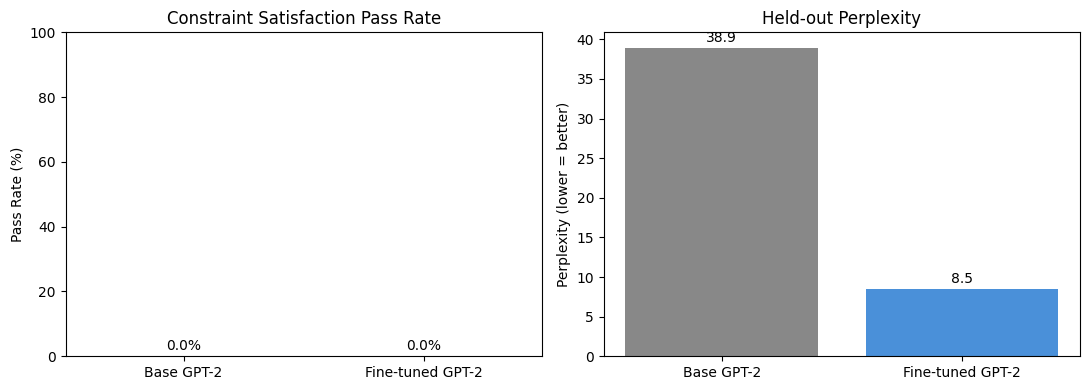

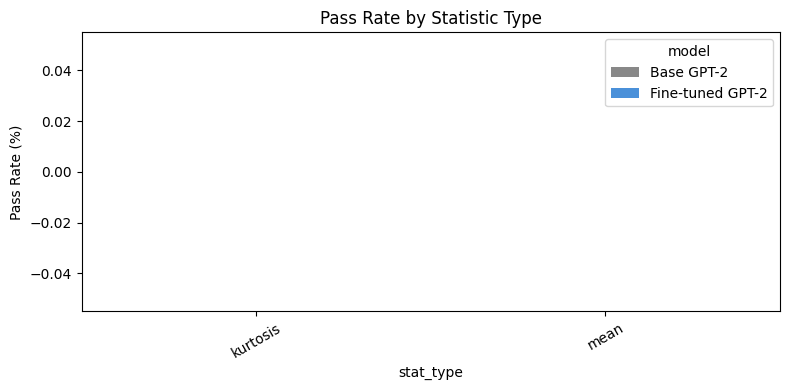

In [11]:
import re
import numpy as np
from scipy.stats import kurtosis
import matplotlib.pyplot as plt

# --- parse target constraint from the prompt ---
def parse_constraint(prompt_text):
    m = re.search(r"satisfying:\s*(\w+)\s*=\s*(-?\d+\.?\d*)", prompt_text)
    if m:
        return m.group(1), float(m.group(2))
    return None, None

# --- extract numbers the model actually generated ---
def extract_numbers(generated_text):
    nums = re.findall(r"-?\d+\.?\d*", generated_text)
    return [float(n) for n in nums if n not in ("", "-", ".")]

# --- compute the real statistic from generated numbers ---
def compute_stat(stat_type, numbers):
    if len(numbers) < 2:
        return None
    arr = np.array(numbers)
    try:
        if stat_type == "median":
            return float(np.median(arr))
        elif stat_type == "mean":
            return float(np.mean(arr))
        elif stat_type == "variance":
            return float(np.var(arr))
        elif stat_type == "kurtosis":
            return float(kurtosis(arr))
        elif stat_type == "correlation":
            return None  # can't score without paired X,Y
    except Exception:
        return None
    return None

# --- pass/fail check within tolerance ---
def check_pass(stat_type, target, generated_text, tolerance=0.1):
    numbers = extract_numbers(generated_text)
    computed = compute_stat(stat_type, numbers)
    if computed is None:
        return None, computed  # unscoreable, not a fail
    passed = abs(computed - target) <= tolerance * max(abs(target), 1)
    return passed, computed

# --- run eval over a results dataframe ---
def evaluate_pass_rate(results_df, generated_col):
    records = []
    for _, row in results_df.iterrows():
        stat_type, target = parse_constraint(row["prompt"])
        if stat_type is None:
            continue
        passed, computed = check_pass(stat_type, target, row[generated_col])
        records.append({
            "prompt": row["prompt"], "stat_type": stat_type,
            "target": target, "computed": computed, "passed": passed
        })
    df = pd.DataFrame(records)
    scoreable = df[df["passed"].notna()]
    pass_rate = scoreable["passed"].mean() * 100 if len(scoreable) else float("nan")
    return df, pass_rate

baseline_eval_df, baseline_pass_rate = evaluate_pass_rate(baseline_df, "generated_baseline")
ft_eval_df, ft_pass_rate = evaluate_pass_rate(ft_df, "generated_finetuned")

print(f"Baseline GPT-2 pass rate:    {baseline_pass_rate:.1f}%")
print(f"Fine-tuned GPT-2 pass rate:  {ft_pass_rate:.1f}%")
print(f"Baseline perplexity:        {baseline_ppl:.2f}")
print(f"Fine-tuned perplexity:      {finetuned_ppl:.2f}")

# --- Chart 1: Pass rate comparison ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(["Base GPT-2", "Fine-tuned GPT-2"], [baseline_pass_rate, ft_pass_rate],
            color=["#888888", "#4a90d9"])
axes[0].set_ylabel("Pass Rate (%)")
axes[0].set_title("Constraint Satisfaction Pass Rate")
axes[0].set_ylim(0, 100)
for i, v in enumerate([baseline_pass_rate, ft_pass_rate]):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha="center")

# --- Chart 2: Perplexity comparison ---
axes[1].bar(["Base GPT-2", "Fine-tuned GPT-2"], [baseline_ppl, finetuned_ppl],
            color=["#888888", "#4a90d9"])
axes[1].set_ylabel("Perplexity (lower = better)")
axes[1].set_title("Held-out Perplexity")
for i, v in enumerate([baseline_ppl, finetuned_ppl]):
    axes[1].text(i, v + max(baseline_ppl, finetuned_ppl) * 0.02, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.savefig("gpt2_before_after_comparison.png")
plt.show()

# --- Chart 3: Pass rate broken down by stat type (only scoreable types) ---
merged_breakdown = pd.concat([
    baseline_eval_df.assign(model="Base GPT-2"),
    ft_eval_df.assign(model="Fine-tuned GPT-2")
])
breakdown = (
    merged_breakdown[merged_breakdown["passed"].notna()]
    .groupby(["stat_type", "model"])["passed"]
    .mean()
    .mul(100)
    .unstack()
)
breakdown.plot(kind="bar", figsize=(8, 4), color=["#888888", "#4a90d9"])
plt.ylabel("Pass Rate (%)")
plt.title("Pass Rate by Statistic Type")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("gpt2_pass_rate_by_stat_type.png")
plt.show()